# 05 - Análisis financiero de Movies

**Alcance.** Este bloque analiza exclusivamente las películas con `budget > 0` y `revenue > 0` en `movies_financial_valid`. Corresponde a la evidencia financiera del storytelling EP1.

**Definición oficial.** ROI aproximado = `revenue / budget` (multiplicador). No se interpreta como utilidad neta ni como ROI porcentual clásico.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_cleaning import build_catalog_views
from src.financial_rules import build_financial_analysis, validate_financial_view
from src.visualizations import (
    plot_budget_vs_revenue,
    plot_low_budget_high_return,
    plot_top_revenue,
    plot_top_roi,
)

In [2]:
# La lectura de los RAW ocurre solo dentro de la preparación aprobada.
views = build_catalog_views(
    project_root / 'data/raw/netflix_movies_detailed_up_to_2025.csv',
    project_root / 'data/raw/netflix_tv_shows_detailed_up_to_2025.csv',
)
movies_financial_valid = views['movies_financial_valid']
validate_financial_view(movies_financial_valid)

assert len(movies_financial_valid) == 3_540
assert movies_financial_valid['show_id'].nunique() == 3_540
assert movies_financial_valid['budget'].gt(0).all()
assert movies_financial_valid['revenue'].gt(0).all()

analysis = build_financial_analysis(movies_financial_valid, total_movies=16_000)
financial = analysis['financial_movies']
display(Markdown('## Contrato financiero validado'))
display(analysis['financial_kpis'])

## Contrato financiero validado

,kpi,value,unit,definition
0,Cobertura financiera,2.212500e+01,% de Movies,Películas elegibles sobre Movies totales.
1,Películas elegibles,3.540000e+03,películas,Filas con budget > 0 y revenue > 0.
2,Presupuesto total,1.259608e+11,USD,Suma de budget en la vista financiera.
3,Presupuesto promedio,3.558214e+07,USD,Media de budget en la vista financiera.
4,Presupuesto mediano,1.500000e+07,USD,Mediana de budget ante asimetría.
5,Ingresos totales,3.673714e+11,USD,Suma de revenue en la vista financiera.
6,Ingresos promedio,1.037772e+08,USD,Media de revenue en la vista financiera.
7,Ingresos medianos,2.380000e+07,USD,Mediana de revenue ante asimetría.
8,ROI aproximado promedio,7.815457e+02,multiplicador,Media de revenue / budget por película.
9,ROI aproximado mediano,1.700033e+00,multiplicador,Mediana de revenue / budget por película.


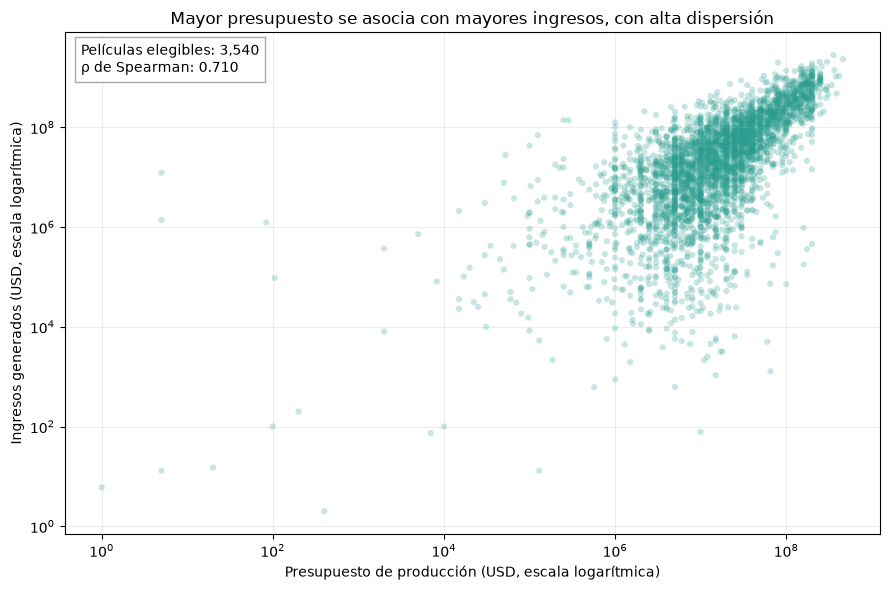

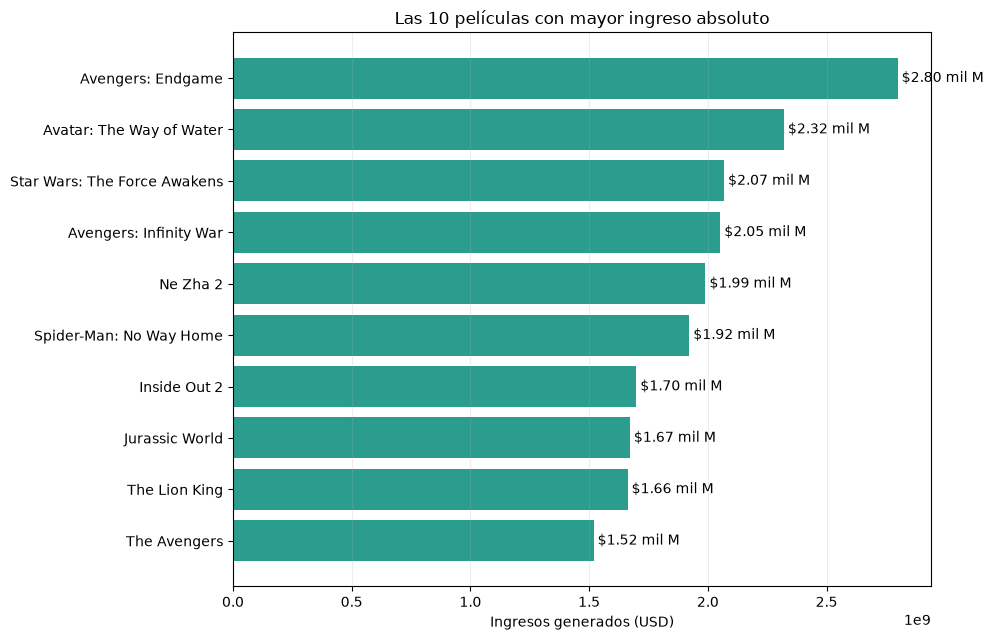

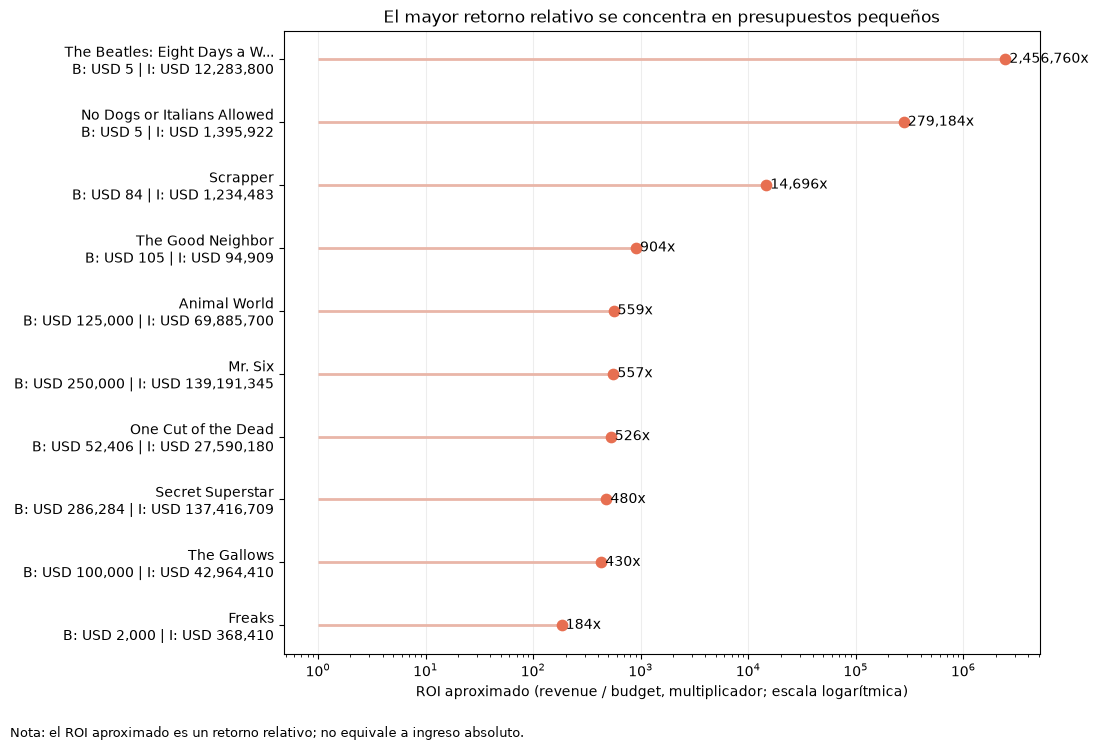

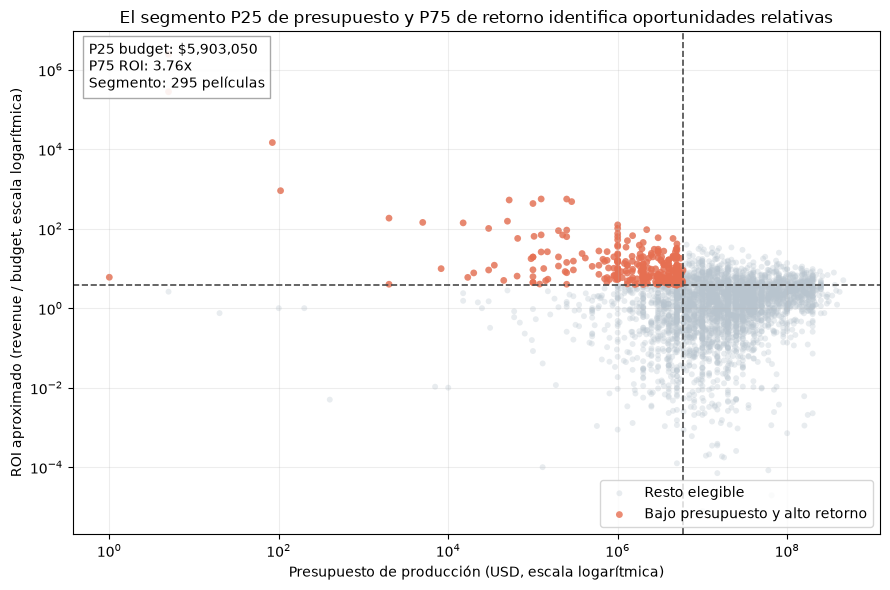

In [3]:
figures_dir = project_root / 'outputs/figures'
figures_dir.mkdir(parents=True, exist_ok=True)
rho = analysis['financial_association'].iloc[0]['spearman_rho']

fig = plot_budget_vs_revenue(financial, rho)
fig.savefig(figures_dir / 'ignacio_budget_vs_revenue.png', dpi=180, bbox_inches='tight')
plt.show()

fig = plot_top_revenue(analysis['top_revenue'])
fig.savefig(figures_dir / 'ignacio_top_ingresos.png', dpi=180, bbox_inches='tight')
plt.show()

fig = plot_top_roi(analysis['top_roi'])
fig.savefig(figures_dir / 'ignacio_top_roi.png', dpi=180, bbox_inches='tight')
plt.show()

fig = plot_low_budget_high_return(financial, analysis['low_budget_thresholds'])
fig.savefig(figures_dir / 'ignacio_bajo_presupuesto_alto_retorno.png', dpi=180, bbox_inches='tight')
plt.show()

In [4]:
threshold = analysis['low_budget_thresholds'].iloc[0]
leader_revenue = analysis['top_revenue'].iloc[0]
leader_roi = analysis['top_roi'].iloc[0]
display(Markdown(f'''## Storytelling financiero

**Audiencia: Directorio y Adquisición. Propósito:** evaluar la evidencia financiera disponible para decisiones de inversión.

**Hallazgo 1 - inversión e ingresos.** La asociación de Spearman entre presupuesto e ingresos es **{rho:.3f}**. El scatter usa escalas logarítmicas porque ambas variables son asimétricas; los valores originales no se transforman para KPIs.

**Hallazgo 2 - ingreso absoluto.** *{leader_revenue.title}* lidera el Top 10 de ingresos con **${leader_revenue.revenue:,.0f}**. Este ranking responde a magnitud de ingreso, no a retorno relativo.

**Hallazgo 3 - retorno relativo.** *{leader_roi.title}* lidera el ROI aproximado con **{leader_roi.roi_approx:,.2f}x**, sobre un presupuesto de **${leader_roi.budget:,.0f}**. Un multiplicador alto debe interpretarse junto con su base de inversión.

**Implicación.** El segmento de presupuesto reducido (<= P25: ${threshold.budget_p25:,.0f}) y retorno alto (>= P75: {threshold.roi_approx_p75:.2f}x) contiene **{int(threshold.titles):,}** películas. Sirve para priorizar una evaluación cualitativa de oportunidades, no para inferir causalidad ni garantizar resultados futuros.

**Limitación.** El bloque cubre 3.540 de 16.000 Movies (22,125 %); no describe todo el catálogo ni atribuye los ingresos a decisiones de StreamView.'''))

display(Markdown('## Rankings auditables'))
display(analysis['top_revenue'])
display(analysis['top_roi'])

## Storytelling financiero

**Audiencia: Directorio y Adquisición. Propósito:** evaluar la evidencia financiera disponible para decisiones de inversión.

**Hallazgo 1 - inversión e ingresos.** La asociación de Spearman entre presupuesto e ingresos es **0.710**. El scatter usa escalas logarítmicas porque ambas variables son asimétricas; los valores originales no se transforman para KPIs.

**Hallazgo 2 - ingreso absoluto.** *Avengers: Endgame* lidera el Top 10 de ingresos con **$2,799,439,100**. Este ranking responde a magnitud de ingreso, no a retorno relativo.

**Hallazgo 3 - retorno relativo.** *The Beatles: Eight Days a Week - The Touring Years* lidera el ROI aproximado con **2,456,760.00x**, sobre un presupuesto de **$5**. Un multiplicador alto debe interpretarse junto con su base de inversión.

**Implicación.** El segmento de presupuesto reducido (<= P25: $5,903,050) y retorno alto (>= P75: 3.76x) contiene **295** películas. Sirve para priorizar una evaluación cualitativa de oportunidades, no para inferir causalidad ni garantizar resultados futuros.

**Limitación.** El bloque cubre 3.540 de 16.000 Movies (22,125 %); no describe todo el catálogo ni atribuye los ingresos a decisiones de StreamView.

## Rankings auditables

,rank,show_id,title,budget,revenue,roi_approx
0,1,299534,Avengers: Endgame,356000000,2799439100,7.863593
1,2,76600,Avatar: The Way of Water,460000000,2320250281,5.044022
2,3,140607,Star Wars: The Force Awakens,245000000,2068223624,8.441729
3,4,299536,Avengers: Infinity War,300000000,2052415039,6.841383
4,5,980477,Ne Zha 2,80000000,1990000000,24.875000
5,6,634649,Spider-Man: No Way Home,200000000,1921847111,9.609236
6,7,1022789,Inside Out 2,200000000,1698863816,8.494319
7,8,135397,Jurassic World,150000000,1671537444,11.143583
8,9,420818,The Lion King,260000000,1662020819,6.392388
9,10,24428,The Avengers,220000000,1518815515,6.903707


,rank,show_id,title,budget,revenue,roi_approx
0,1,391698,The Beatles: Eight Days a Week - The Touring Y...,5,12283800,2.456760e+06
1,2,715385,No Dogs or Italians Allowed,5,1395922,2.791844e+05
2,3,935906,Scrapper,84,1234483,1.469623e+04
3,4,893086,The Good Neighbor,105,94909,9.038952e+02
4,5,518764,Animal World,125000,69885700,5.590856e+02
5,6,357940,Mr. Six,250000,139191345,5.567654e+02
6,7,513434,One Cut of the Dead,52406,27590180,5.264699e+02
7,8,441889,Secret Superstar,286284,137416709,4.800014e+02
8,9,299245,The Gallows,100000,42964410,4.296441e+02
9,10,539892,Freaks,2000,368410,1.842050e+02
